In [1]:
## Parallel programming imports
import ipyparallel as ipp
from mpi4py import MPI
cluster = ipp.Cluster(engines = "mpi", n = 9)
rc = cluster.start_and_connect_sync()

Starting 9 engines with <class 'ipyparallel.cluster.launcher.MPIEngineSetLauncher'>


  0%|          | 0/9 [00:00<?, ?engine/s]

In [2]:
%%px

import importlib.util

if importlib.util.find_spec("petsc4py") is not None:
    import dolfinx

    if not dolfinx.has_petsc:
        print("This demo requires DOLFINx to be compiled with PETSc enabled.")
        exit(0)
    from petsc4py.PETSc import ScalarType  # type: ignore
else:
    print("This demo requires petsc4py.")
    exit(0)

# +
import numpy as np

import ufl
from dolfinx import fem, io, mesh, plot, la
from dolfinx.fem.petsc import LinearProblem
import matplotlib.pyplot as plt

import time

%%px
from dolfinx.io import gmshio 
import pyvista as pv
import gmsh
import meshio

# Read the .msh file
#model = meshio.read("untitled.msh")
#gmsh.initialize()
#model = gmsh.open("untitled.msh")

msh, cell_tags, facet_tags = gmshio.read_from_msh(
    filename="BoxMeshHexRecombined.msh", 
    comm=MPI.COMM_WORLD)
#gmsh.finalize()

#msh.geometry.x[:] /= 1000
#print(len(msh.geometry.x[:]))

print(msh.topology.dim)
msh.topology.create_connectivity(msh.topology.dim-1, msh.topology.dim)


In [3]:
%%px


import gmsh
from dolfinx.io import gmshio 
from dolfinx.graph import partitioner_scotch
from dolfinx.io import XDMFFile, VTXWriter

gmsh.initialize()
gmsh.open("BoxMesh.geo")
model = gmsh.model
model_name = model.getCurrent()

#partitioner = dolfinx.mesh.create_cell_partitioner(partitioner_scotch())
partitioner = mesh.create_cell_partitioner(mesh.GhostMode.shared_facet)
umesh, ucell_tags, ufacet_tags = gmshio.model_to_mesh( 
    model, 
    MPI.COMM_WORLD, 
    rank = 0,
    gdim = 3, 
    partitioner = partitioner 
)


gmsh.finalize() 
#mesh, cell_tags, facet_tags = model_to_mesh(gmsh.model, MPI.COMM_WORLD, model_rank)

[stdout:5] Info    : Reading 'BoxMesh.geo'...
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 30%] Meshing curve 4 (Line)
Info    : [ 40%] Meshing curve 5 (Line)
Info    : [ 50%] Meshing curve 6 (Line)
Info    : [ 60%] Meshing curve 7 (Line)
Info    : [ 60%] Meshing curve 8 (Line)
Info    : [ 70%] Meshing curve 9 (Line)
Info    : [ 80%] Meshing curve 10 (Line)
Info    : [ 90%] Meshing curve 11 (Line)
Info    : [100%] Meshing curve 12 (Line)
Info    : Done meshing 1D (Wall 0.00124235s, CPU 0.001395s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Transfinite)
Info    : [ 20%] Meshing surface 2 (Transfinite)
Info    : [ 40%] Meshing surface 3 (Transfinite)
Info    : [ 60%] Meshing surface 4 (Transfinite)
Info    : [ 70%] Meshing surface 5 (Transfinite)
Info    : [ 90%] Meshing surface 6 (Transfinite)
Info    : Done meshing 2D (Wall 0.0211124s, CPU 0s)
Info    : Meshing

[stdout:8] Info    : Reading 'BoxMesh.geo'...
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 30%] Meshing curve 4 (Line)
Info    : [ 40%] Meshing curve 5 (Line)
Info    : [ 50%] Meshing curve 6 (Line)
Info    : [ 60%] Meshing curve 7 (Line)
Info    : [ 60%] Meshing curve 8 (Line)
Info    : [ 70%] Meshing curve 9 (Line)
Info    : [ 80%] Meshing curve 10 (Line)
Info    : [ 90%] Meshing curve 11 (Line)
Info    : [100%] Meshing curve 12 (Line)
Info    : Done meshing 1D (Wall 0.000785476s, CPU 0.002344s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Transfinite)
Info    : [ 20%] Meshing surface 2 (Transfinite)
Info    : [ 40%] Meshing surface 3 (Transfinite)
Info    : [ 60%] Meshing surface 4 (Transfinite)
Info    : [ 70%] Meshing surface 5 (Transfinite)
Info    : [ 90%] Meshing surface 6 (Transfinite)
Info    : Done meshing 2D (Wall 0.0472748s, CPU 0.049902s)
Info    :

[stdout:2] Info    : Reading 'BoxMesh.geo'...
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 30%] Meshing curve 4 (Line)
Info    : [ 40%] Meshing curve 5 (Line)
Info    : [ 50%] Meshing curve 6 (Line)
Info    : [ 60%] Meshing curve 7 (Line)
Info    : [ 60%] Meshing curve 8 (Line)
Info    : [ 70%] Meshing curve 9 (Line)
Info    : [ 80%] Meshing curve 10 (Line)
Info    : [ 90%] Meshing curve 11 (Line)
Info    : [100%] Meshing curve 12 (Line)
Info    : Done meshing 1D (Wall 0.000931212s, CPU 0.001476s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Transfinite)
Info    : [ 20%] Meshing surface 2 (Transfinite)
Info    : [ 40%] Meshing surface 3 (Transfinite)
Info    : [ 60%] Meshing surface 4 (Transfinite)
Info    : [ 70%] Meshing surface 5 (Transfinite)
Info    : [ 90%] Meshing surface 6 (Transfinite)
Info    : Done meshing 2D (Wall 0.0073889s, CPU 0.011696s)
Info    :

[stdout:4] Info    : Reading 'BoxMesh.geo'...
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 30%] Meshing curve 4 (Line)
Info    : [ 40%] Meshing curve 5 (Line)
Info    : [ 50%] Meshing curve 6 (Line)
Info    : [ 60%] Meshing curve 7 (Line)
Info    : [ 60%] Meshing curve 8 (Line)
Info    : [ 70%] Meshing curve 9 (Line)
Info    : [ 80%] Meshing curve 10 (Line)
Info    : [ 90%] Meshing curve 11 (Line)
Info    : [100%] Meshing curve 12 (Line)
Info    : Done meshing 1D (Wall 0.000896475s, CPU 0.001804s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Transfinite)
Info    : [ 20%] Meshing surface 2 (Transfinite)
Info    : [ 40%] Meshing surface 3 (Transfinite)
Info    : [ 60%] Meshing surface 4 (Transfinite)
Info    : [ 70%] Meshing surface 5 (Transfinite)
Info    : [ 90%] Meshing surface 6 (Transfinite)
Info    : Done meshing 2D (Wall 0.0199188s, CPU 0s)
Info    : Meshin

[stdout:1] Info    : Reading 'BoxMesh.geo'...
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 30%] Meshing curve 4 (Line)
Info    : [ 40%] Meshing curve 5 (Line)
Info    : [ 50%] Meshing curve 6 (Line)
Info    : [ 60%] Meshing curve 7 (Line)
Info    : [ 60%] Meshing curve 8 (Line)
Info    : [ 70%] Meshing curve 9 (Line)
Info    : [ 80%] Meshing curve 10 (Line)
Info    : [ 90%] Meshing curve 11 (Line)
Info    : [100%] Meshing curve 12 (Line)
Info    : Done meshing 1D (Wall 0.000760322s, CPU 0.0019s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Transfinite)
Info    : [ 20%] Meshing surface 2 (Transfinite)
Info    : [ 40%] Meshing surface 3 (Transfinite)
Info    : [ 60%] Meshing surface 4 (Transfinite)
Info    : [ 70%] Meshing surface 5 (Transfinite)
Info    : [ 90%] Meshing surface 6 (Transfinite)
Info    : Done meshing 2D (Wall 0.00603446s, CPU 0.012624s)
Info    : 

...

[stderr:4] Warning : Boolean fragments skipped - too few arguments


[stderr:2] Warning : Boolean fragments skipped - too few arguments


[stderr:7] Warning : Boolean fragments skipped - too few arguments


[stderr:0] Warning : Boolean fragments skipped - too few arguments


[stderr:1] Warning : Boolean fragments skipped - too few arguments


In [4]:
%%px
import petsc4py
import sys
petsc4py.init(sys.argv)
from petsc4py import PETSc
from dolfinx.fem import (Constant,  Function, functionspace, assemble_scalar, 
                         dirichletbc, form, locate_dofs_topological, Function)
from dolfinx.mesh import create_unit_square, locate_entities, meshtags
from ufl import (FacetNormal, Measure, SpatialCoordinate, TestFunction, TrialFunction, 
                 div, dot, dx, grad, inner, lhs, rhs, system)
import pyvista
from dolfinx.plot import vtk_mesh
import dolfinx.fem.petsc as petsc
from dolfinx.geometry import bb_tree, compute_colliding_cells, compute_collisions_points

In [5]:
%%px
z_max = 0.2
msh = mesh.create_box(
    comm=MPI.COMM_WORLD,
    points=((0.0, 0.0, 0.0), (0.1, 0.1, z_max)),
    n=(20, 20, 40),
    #cell_type=mesh.CellType.tetrahedron,
    cell_type=mesh.CellType.hexahedron,
    ghost_mode = dolfinx.mesh.GhostMode.shared_facet
)
umesh.topology.create_connectivity(umesh.topology.dim-1, umesh.topology.dim)
V = fem.functionspace(umesh, ("Lagrange", 1))

top_marker, bottom_marker, sides_marker = 13, 14, 15

print(len(ucell_tags.values))

[stdout:3] 30757


[stdout:0] 30822


[stdout:2] 30568


[stdout:1] 30751


[stdout:5] 31178


[stdout:8] 30628


[stdout:6] 30563


[stdout:7] 30539


[stdout:4] 31277


# To apply the Dirichlet boundary conditions, we find the mesh facets
# (entities of topological co-dimension 1) that lie on the boundary
# $\Gamma_D$ using {py:func}`locate_entities_boundary
# <dolfinx.mesh.locate_entities_boundary>`. The function is provided
# with a 'marker' function that returns `True` for points `x` on the
# boundary and `False` otherwise.
old_facets_sides = mesh.locate_entities_boundary(
    msh,
    dim=(msh.topology.dim - 1),
    marker=lambda x: np.isclose(x[0], 0.0) | np.isclose(x[0], 1.0) | np.isclose(x[1], 0.0) | np.isclose(x[1], 1.0),
)

#enforce Dirichlet BC on the facets of the heatplate (z=0)
old_facets_heatplate = mesh.locate_entities_boundary(
    msh,
    dim=(msh.topology.dim - 1),
    marker=lambda x: np.isclose(x[2], 0.0),
)

#enforce Neumann BC on the top facets where the laser works (z=z_max)
old_facets_laser = mesh.locate_entities_boundary(
    msh,
    dim=(msh.topology.dim - 1),
    marker=lambda x: np.isclose(x[2], z_max),
)

In [6]:
%%px
# from Jokken's tutorial: https://jsdokken.com/dolfinx-tutorial/chapter3/robin_neumann_dirichlet.html 
# 1: sides  
# 2: heatplate 
# 3: laser 
boundaries = [(sides_marker, lambda x: np.isclose(x[0], 0.0) | np.isclose(x[0], 1.0) | np.isclose(x[1], 0.0) | np.isclose(x[1], 1.0)),
              (bottom_marker, lambda x: np.isclose(x[2], 0.0)),
              (top_marker, lambda x: np.isclose(x[2], z_max))]

facet_indices, facet_markers = [], []
fdim = umesh.topology.dim - 1
for (marker, locator) in boundaries:
    facets = locate_entities(msh, fdim, locator)
    facet_indices.append(facets)
    facet_markers.append(np.full_like(facets, marker))
facet_indices = np.hstack(facet_indices).astype(np.int32)
facet_markers = np.hstack(facet_markers).astype(np.int32)
sorted_facets = np.argsort(facet_indices)
facet_tag = meshtags(msh, fdim, facet_indices[sorted_facets], facet_markers[sorted_facets])

In [7]:
%%px

#create custom ds for where Neumann BC needs to be applied 
ds = Measure("ds", domain=umesh, subdomain_data=ufacet_tags)
#ds_old = Measure("ds", domain=msh, subdomain_data=facet_tag)

In [8]:
%%px
# let's go: transient heat equation
t = 0.0
delta_t = Constant(umesh, 0.1) # [s] 
t_end = 700 # [s]
n_timesteps = int(t_end/delta_t.value) + 1

# Define the problem parameters
rho = Constant(umesh, 4700.0) #[kg/m^3]
cp = Constant(umesh, 500.0) #[J/(kg*K)]
k = Constant(umesh, 20.0) #[W/(m*K)]
h_bulk_powder = 10.0 # [W/(m^2*K)]
#q_laserpower = Constant(msh, 2000000.0) # [W/m^2]
T_heatplate_ = Constant(umesh, 500.0) # [K]
q_powder = Constant(umesh, h_bulk_powder * 300.0) # [W/m^2] where 300 is the temperature difference between powder and part 
T_initial = Constant(umesh, 600.0) # [K]

v_laser = 1.0 # [m/s] https://www.sciencedirect.com/science/article/pii/S2238785424027923
P_laser = 250.0 # [W]
h_hatch_um = 100.0 # [um]
h_hatch = h_hatch_um * 1e-6 # [m]
t_interlayer = 10.0 # [s]

n_layers_lumped = 4

# --> 
n_hatches = 0.1/h_hatch 
length_hatch = 0.1 # [m]
t_true = n_hatches * length_hatch / v_laser # [s]
ved = P_laser/(v_laser * h_hatch * t_true)

t_true_scanning = 0.1**2 / (h_hatch * v_laser) # [s]
E_tot_layer = P_laser * t_true_scanning # [J] 
E_tot = n_layers_lumped * E_tot_layer # [J]
t_tot = n_layers_lumped * (t_true + t_interlayer) # [s]

q_laserpower = Constant(umesh, P_laser / 0.1**2) # [W/m^2]
t_per_layer = t_true_scanning + t_interlayer # [s]


In [9]:
%%px

# Define the test function and trial function
T = TrialFunction(V)
v = TestFunction(V)
T_n = Function(V) # previous time step
T_heatplate = Function(V) # heatplate temperature
x = SpatialCoordinate(umesh)
n = FacetNormal(umesh)

# Define the variational problem
F_list = []

F1 = rho * cp * T * v * dx # goes into a 
F2 = delta_t * k * inner(grad(T), grad(v)) * dx # goes into a 
F3 = - delta_t * k * dot(n, grad(T)) * v * ds 
F4 = - rho * cp * T_n * v * dx # goes into L 

#F = F1+F2+F3+F4

F_list.append(F1)
F_list.append(F2)
#F_list.append(F3)
F_list.append(F4)


#F = rho * cp * T * v * dx + delta_t * k * inner(grad(T), grad(v)) * dx - rho * cp * T_n * v * dx

# define time-dependent BCs
def T_heatplate_function(t): 
    if t >= 0.0: 
        return lambda x: T_heatplate_.value

# Neumann BC depending on T 
def q_laser_function_old(t): 
    if ((t >= 5.0) & (t <= 15.0)) | (t >= 20.0): 
        return q_powder.value*delta_t.value
    else: return -q_laserpower.value*delta_t.value
#t=0.0
def q_laser_function(t): 
    T = t_true_scanning + t_interlayer
    cycle_index = int(t // T)

    if cycle_index >= n_layers_lumped: 
        return 0 
    t_in_cycle = t % T 

    if t_in_cycle < t_true_scanning: 
        return -q_laserpower.value*delta_t.value
    else: return q_powder.value*delta_t.value

#for n_i in range(n_timesteps):
    #t = n_i * delta_t.value
    #print(q_laser_function(t) != q_laser_function(t-delta_t.value))
        #print(q_laser_function(t))
t=0.0
#print(((t >= 5.0) & (t <= 15.0)) | ((t >= 20.0) & (t <= 30.0)))
#print(q_laser_function(t) != q_laser_function(t-delta_t.value))
#print(q_laser_function(t), q_laser_function(t-delta_t.value))


In [10]:
%%px
# We can now create a general boundary condition class.
class BoundaryCondition():
    def __init__(self, type, marker, values):
        self._type = type
        if type == "Dirichlet":
            u_D = Function(V)
            #u_D.interpolate(values)
            u_D.x.array[:] = values  # Assign the provided values to the function
            facets = ufacet_tags.find(marker)
            dofs = locate_dofs_topological(V, fdim, facets)
            self._bc = dirichletbc(u_D, dofs)
        elif type == "Neumann":
            self._bc = inner(values, v) * ds(marker)
        elif type == "Robin":
            self._bc = values[0] * inner(T-values[1], v)* ds(marker)
        else:
            raise TypeError("Unknown boundary condition: {0:s}".format(type))
    @property
    def bc(self):
        return self._bc

    @property
    def type(self):
        return self._type

tdim = msh.topology.dim
fdim = tdim - 1
x = msh.geometry.x

# --- 2. Create necessary mesh connectivity ---
msh.topology.create_connectivity(fdim, 0)
facet_to_vertex = msh.topology.connectivity(fdim, 0)

facet_areas_by_name = {}

for name, marker in boundaries:
    # Find facets matching this marker
    facets = locate_entities(msh, fdim, marker)
    areas = []

    for facet in facets:
        # Get vertex indices of the facet
        offset = facet_to_vertex.offsets[facet]
        end = facet_to_vertex.offsets[facet + 1]
        vertex_indices = facet_to_vertex.array[offset:end]
        coords = x[vertex_indices]

        if coords.shape[0] != 4:
            raise RuntimeError(f"Expected 4 vertices on a quad facet, got {coords.shape[0]}")

        # Compute area using two triangles
        v0, v1, v2, v3 = coords
        a1 = 0.5 * np.linalg.norm(np.cross(v1 - v0, v2 - v0))
        a2 = 0.5 * np.linalg.norm(np.cross(v2 - v0, v3 - v0))
        area = a1 + a2
        areas.append(area)

    facet_areas_by_name[name] = np.array(areas)

In [11]:
%%px
# set BCs initially: 
boundary_conditions = [BoundaryCondition("Neumann", sides_marker, q_powder*delta_t), # sides; goes into L 
                       BoundaryCondition("Dirichlet", bottom_marker, T_heatplate_.value), # heatplate 
                       BoundaryCondition("Neumann", top_marker, q_laser_function(t)) # laser; goes into L 
                       ]
bcs = [] 

for condition in boundary_conditions:
        if condition.type == "Dirichlet":
            bcs.append(condition.bc)
        else:
            F_list.append(condition.bc)

# function for only Dirichlet BCs: OBSOLETE
def set_dirichlet_bcs(t):
    bcs_ = []
    for bc_ in boundary_conditions:
        if bc_.type == "Dirichlet":
            bcs_.append(bc_.bc)
    return bcs_

# assemble the system
F = sum(F_list)

(a, L) = system(F)


In [12]:
%%px
compiled_a = fem.form(a)
A = petsc.assemble_matrix(compiled_a, bcs=bcs)
A.assemble()
compiled_L = fem.form(L)
b = fem.Function(V)
b.x.array[:] = T_initial
T_n.x.array[:] = T_initial

bcs = set_dirichlet_bcs(t)

solver = PETSc.KSP().create(msh.comm)
solver.setOperators(A)
solver.setType("cg")
pc = solver.getPC()
pc.setType("jacobi")

In [13]:
%%px
print(b.x.array[:])

[stdout:0] [600. 600. 600. ... 600. 600. 600.]


[stdout:1] [600. 600. 600. ... 600. 600. 600.]


[stdout:2] [600. 600. 600. ... 600. 600. 600.]


[stdout:5] [600. 600. 600. ... 600. 600. 600.]


[stdout:4] [600. 600. 600. ... 600. 600. 600.]


[stdout:8] [600. 600. 600. ... 600. 600. 600.]


[stdout:6] [600. 600. 600. ... 600. 600. 600.]


[stdout:3] [600. 600. 600. ... 600. 600. 600.]


[stdout:7] [600. 600. 600. ... 600. 600. 600.]


T_0 = Function(V)
# Correct initialization: return an array of zeros, one per mesh point
T_0.interpolate(lambda x: np.full(x.shape[1], T_initial))
T_n = T_0

# Step 1: Convert FEniCSx mesh to PyVista-compatible mesh
cells, cell_types, geometry = vtk_mesh(msh, msh.topology.dim)
grid = pyvista.UnstructuredGrid(cells, cell_types, geometry)

# Step 2: Set initial scalar values before adding the mesh
grid.point_data["Temperature"] = T_0.x.array.real.copy()

# Step 3: Create the plotter and add the mesh with scalars
plotter = pyvista.Plotter()
plotter.open_gif("transient_temperature.gif", fps=10)  # Optional GIF export

# Add mesh (must be after scalar data is attached)
plotter.add_mesh(grid, scalars="Temperature", cmap="plasma", clim=[300, 700], show_edges=True)
plotter.add_scalar_bar("Temperature")

# Optional: Add time display (updates every frame)
text_actor = plotter.add_text("Time: 0.0 s", font_size=14, position="lower_left")

In [14]:
%%px
def average_temperature_at_z(z_target, mesh, temperature_field):
    # Extract the coordinates of all mesh points
    coords = mesh.points
    
    # Find indices of nodes with z coordinate close to z_target
    z_values = coords[:, 2]  # Get the z-component of the points
    z_mask = np.isclose(z_values, z_target, atol=1e-3)  # Choose a tolerance for "closeness"
    
    # Extract temperatures at those points
    temperatures_at_z = temperature_field[z_mask]
    
    # Return the average temperature at those points
    return np.mean(temperatures_at_z) if temperatures_at_z.size > 0 else np.nan

In [15]:
%%px
pyvista.start_xvfb(0.5)  # Start virtual framebuffer for plotting
plotter = pyvista.Plotter()
plotter.open_gif("u_time2.gif")

topology, cells, geometry = plot.vtk_mesh(V)
uh = fem.Function(V)
grid = pyvista.UnstructuredGrid(topology, cells, geometry)
grid.point_data["uh"] = uh.x.array

# Optional: Add time display (updates every frame)
text_actor = plotter.add_text("Time: 0.0 s", font_size=14, position="lower_left")

In [16]:
%%px
viridis = plt.cm.get_cmap("viridis", 25)
sargs = dict(
    title_font_size=25,
    label_font_size=20,
    fmt="%.0f",
    color="black",
    position_x=0.1,
    position_y=0.9,
    width=0.8,
    height=0.08,
)

In [17]:
%%px
renderer = plotter.add_mesh(
    grid,
    show_edges=True,
    lighting=False,
    cmap=viridis,
    scalar_bar_args=sargs,
    clim=[0, 1000],
)

In [18]:
%%px
plotter.view_isometric()
plotter.camera.zoom(0.8)


In [19]:
%%px

x_probe = np.array([[0.05, 0.05, 0.2]])

# Find which cell contains the point (do this only once if the mesh is static)

tdim = umesh.topology.dim
tree = bb_tree(umesh, tdim)
candidates = compute_collisions_points(tree, x_probe)
colliding_cells = compute_colliding_cells(umesh, candidates, x_probe)
cell_ids = colliding_cells.array

rank = MPI.COMM_WORLD.Get_rank()


if len(cell_ids) > 0:
    cell_id = cell_ids[0]  # Get the first (and only) cell ID
    owns_it = True # true on only one rank 
else: owns_it = False

local_rank_value = rank if owns_it else MPI.COMM_WORLD.Get_size()

owning_rank = MPI.COMM_WORLD.allreduce(local_rank_value, op=MPI.MIN)

if owning_rank < MPI.COMM_WORLD.Get_size():
    rank_contains_cellid = rank if rank == owning_rank else None
    rank_contains_cellid = MPI.COMM_WORLD.bcast(rank_contains_cellid, root=owning_rank)
else:
    rank_contains_cellid = None  # Nobody owns the cell


In [20]:
%%px
T_tracker = np.empty(n_timesteps)
Tracker_time = np.empty(n_timesteps)

start_time = time.time()


for n_i in range(n_timesteps):
    t = n_i * delta_t.value  
    
    if q_laser_function(t) != q_laser_function(t-delta_t.value): 
        
        F = sum(F_list[0:3]) + BoundaryCondition("Neumann", top_marker, q_laser_function(t)).bc
        #F = sum(F_list[0:4]) # remove the laser power term from the system
        (a, L) = system(F)
        compiled_a = fem.form(a)
        A = petsc.assemble_matrix(compiled_a, bcs=bcs)
        A.assemble()
        compiled_L = fem.form(L)
        b = fem.Function(V)
        bcs = set_dirichlet_bcs(t)
        
    # assemble RHS 
    b.x.array[:] = 0.0
    petsc.assemble_vector(b.x.petsc_vec, compiled_L)

    # apply BCs 
    #bcs = set_dirichlet_bcs(t)
    petsc.apply_lifting(b.x.petsc_vec, [compiled_a], [bcs])
    b.x.scatter_reverse(la.InsertMode.add)
    fem.petsc.set_bc(b.x.petsc_vec, bcs)

    # Solve linear problem
    solver.solve(b.x.petsc_vec, uh.x.petsc_vec)
    uh.x.scatter_forward()

    # Update Tn
    T_n.x.array[:] = uh.x.array

    #print temperature at point on side face at z=0.1: 
    value = uh.eval(x_probe, cell_id)
    print(f"Time {t:.2f} s: T({x_probe}) = {value[0]:.3f} K")
    #T_tracker[n_i] = value[0]

end_time = time.time()
print("It took", end_time - start_time, "s to solve the problem.")

#plotter.show() 

start_time = time.time()
for n_i in range(n_timesteps):
    t = n_i * delta_t.value  
        
    if t == 5.0: 
        F = sum(F_list[0:4])
        (a, L) = system(F)
        compiled_a = fem.form(a)
        A = petsc.assemble_matrix(compiled_a, bcs=bcs)
        A.assemble()
        compiled_L = fem.form(L)
        b = fem.Function(V)
            
    # assemble RHS 
    b.x.array[:] = 0.0
    petsc.assemble_vector(b.x.petsc_vec, compiled_L)

    # apply BCs 
    bcs = set_dirichlet_bcs(t)
    petsc.apply_lifting(b.x.petsc_vec, [compiled_a], [bcs])
    b.x.scatter_reverse(la.InsertMode.add)
    fem.petsc.set_bc(b.x.petsc_vec, bcs)

    # Solve linear problem
    solver.solve(b.x.petsc_vec, uh.x.petsc_vec)
    uh.x.scatter_forward()

    # Update Tn
    T_n.x.array[:] = uh.x.array

end_time = time.time()
print(f"Time taken for {n_timesteps} time steps: {end_time - start_time:.2f} seconds")

In [21]:
%%px

n_i = 0 
start_time = time.time()
#with dolfinx.io.XDMFFile(MPI.COMM_WORLD, "solution.xdmf", "w") as xdmf_file:
#    xdmf_file.write_mesh(msh)  # Write the mesh once to the XDMF file

while t < t_end:
    t += delta_t.value
    Tracker_time[n_i] = t

    t_in_cycle = t % t_per_layer
    t_in_cycle_earlier = (t - delta_t.value) % t_per_layer

    if (
        t_in_cycle_earlier < t_true_scanning and t_in_cycle >= t_true_scanning  # scanning → interlayer
        or t_in_cycle_earlier >= t_true_scanning and t_in_cycle < t_true_scanning  # interlayer → scanning
        or t_in_cycle_earlier > t_in_cycle  # new layer (cycle reset)
    ):
        print("power changed")
        F = sum(F_list[0:3]) + BoundaryCondition("Neumann", top_marker, q_laser_function(t)).bc
        (a, L) = system(F)
        compiled_a = fem.form(a)
        A = petsc.assemble_matrix(compiled_a, bcs=bcs)
        A.assemble()
        compiled_L = fem.form(L)
        b = fem.Function(V)
        bcs = set_dirichlet_bcs(t)

    # assemble RHS 
    b.x.array[:] = 0.0
    petsc.assemble_vector(b.x.petsc_vec, compiled_L)

    # apply BCs 
    #bcs = set_dirichlet_bcs(t)
    petsc.apply_lifting(b.x.petsc_vec, [compiled_a], [bcs])
    b.x.scatter_reverse(la.InsertMode.add)
    fem.petsc.set_bc(b.x.petsc_vec, bcs)

    # Solve linear problem
    solver.solve(b.x.petsc_vec, uh.x.petsc_vec)
    uh.x.scatter_forward()

    # Update Tn
    T_n.x.array[:] = uh.x.array

    # Update plotter
    # Update time display
    #text_actor.SetText(0, f"Time: {t:.2f} s")
    #plotter.update_scalars(uh.x.array, render=False)
    #plotter.write_frame()

    #print temperature at point on side face at z=0.1: 
    if rank_contains_cellid == MPI.COMM_WORLD.Get_rank():
        value = uh.eval(x_probe, cell_id)
        print(f"Time {t:.6f} s: T({x_probe}) = {value[0]:.3f} K")
        T_tracker[n_i] = value[0]

        # Update delta_t
        #old_delta_t = dt
        #delta_t_scheduler.update_delta_t(value[0])
        #dt = delta_t_scheduler.delta_t
        #print("n_i: ", n_i, "delta_t: ", dt)

    n_i += 1
end_time = time.time()
print("It took", end_time - start_time, "s to solve the problem.")

#plotter.show() 
plotter.close()  # Close the plotter when done

[stdout:8] Time 0.100000 s: T([[0.05 0.05 0.2 ]]) = 600.726 K
Time 0.200000 s: T([[0.05 0.05 0.2 ]]) = 601.299 K
Time 0.300000 s: T([[0.05 0.05 0.2 ]]) = 601.770 K
Time 0.400000 s: T([[0.05 0.05 0.2 ]]) = 602.168 K
Time 0.500000 s: T([[0.05 0.05 0.2 ]]) = 602.516 K
Time 0.600000 s: T([[0.05 0.05 0.2 ]]) = 602.826 K
Time 0.700000 s: T([[0.05 0.05 0.2 ]]) = 603.107 K
Time 0.800000 s: T([[0.05 0.05 0.2 ]]) = 603.365 K
Time 0.900000 s: T([[0.05 0.05 0.2 ]]) = 603.605 K
Time 1.000000 s: T([[0.05 0.05 0.2 ]]) = 603.830 K
Time 1.100000 s: T([[0.05 0.05 0.2 ]]) = 604.043 K
Time 1.200000 s: T([[0.05 0.05 0.2 ]]) = 604.244 K
Time 1.300000 s: T([[0.05 0.05 0.2 ]]) = 604.437 K
Time 1.400000 s: T([[0.05 0.05 0.2 ]]) = 604.621 K
Time 1.500000 s: T([[0.05 0.05 0.2 ]]) = 604.799 K
Time 1.600000 s: T([[0.05 0.05 0.2 ]]) = 604.970 K
Time 1.700000 s: T([[0.05 0.05 0.2 ]]) = 605.135 K
Time 1.800000 s: T([[0.05 0.05 0.2 ]]) = 605.295 K
Time 1.900000 s: T([[0.05 0.05 0.2 ]]) = 605.451 K
Time 2.000000 s: T([

%px:   0%|          | 0/9 [00:00<?, ?tasks/s]

[stdout:3] power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
It took 43.37770748138428 s to solve the problem.


[stdout:6] power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
It took 43.37655735015869 s to solve the problem.


[stdout:4] power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
It took 43.377575159072876 s to solve the problem.


[stdout:7] power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
It took 43.37365484237671 s to solve the problem.


[stdout:2] power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
It took 43.376554012298584 s to solve the problem.


[stdout:1] power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
It took 43.377074241638184 s to solve the problem.


[stdout:0] power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
It took 43.378251791000366 s to solve the problem.


[stdout:5] power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
power changed
It took 43.37735724449158 s to solve the problem.


[output:8]

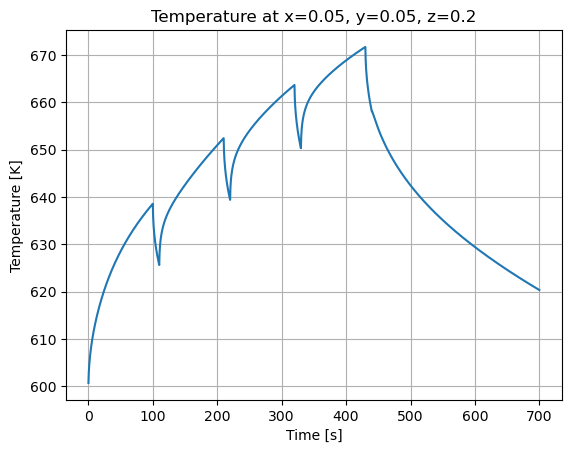

[output:8]

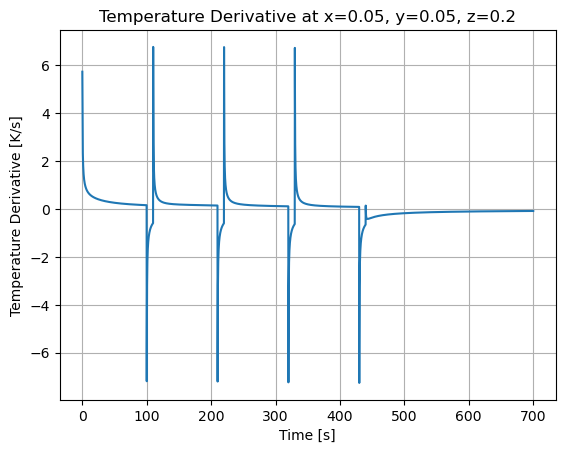

In [22]:
%%px

if rank_contains_cellid == MPI.COMM_WORLD.Get_rank():
    #plot the temperature curve of T_tracker
    plt.figure()
    plt.plot(Tracker_time[:n_i], T_tracker[:n_i])
    plt.xlabel("Time [s]")
    plt.ylabel("Temperature [K]")
    plt.title("Temperature at x=0.05, y=0.05, z=0.2")
    plt.grid()
    #plt.savefig("temperature_curve2_quad.png")
    plt.show()

    T_tracker_derivative = np.gradient(T_tracker[:n_i], Tracker_time[:n_i])
    plt.figure()
    plt.plot(Tracker_time[:n_i], T_tracker_derivative)
    plt.xlabel("Time [s]")
    plt.ylabel("Temperature Derivative [K/s]")
    plt.title("Temperature Derivative at x=0.05, y=0.05, z=0.2")
    plt.grid()
    #plt.savefig("temperature_derivative_curve2_quad.png")
    plt.show()



In [506]:
plotter.close()

In [23]:
import pyvista
from dolfinx.plot import vtk_mesh

# Get VTK-compatible mesh and cell type
grid = pyvista.UnstructuredGrid(*vtk_mesh(msh, msh.topology.dim))

# Add solution values to the grid
grid.point_data["Temperature"] = T_n.x.array.real

# Plot
plotter = pyvista.Plotter()
plotter.add_mesh(grid, scalars="Temperature", cmap="coolwarm", show_edges=True)
plotter.add_scalar_bar("Temperature")
plotter.show()


Widget(value='<iframe src="http://localhost:41693/index.html?ui=P_0x7fa9145d6e90_0&reconnect=auto" class="pyvi…

In [24]:
import pyvista
from dolfinx.plot import vtk_mesh

# Visualize solution
pyvista.start_xvfb()
pyvista_cells, cell_types, geometry = vtk_mesh(V)
grid = pyvista.UnstructuredGrid(pyvista_cells, cell_types, geometry)
grid.point_data["u"] = uh.x.array
grid.set_active_scalars("u")

plotter = pyvista.Plotter()
plotter.add_text("uh", position="upper_edge", font_size=14, color="black")
plotter.add_mesh(grid, show_edges=True)
plotter.view_xy()
plotter.show()
if not pyvista.OFF_SCREEN:
    plotter.show()
else:
    figure = plotter.screenshot("robin_neumann_dirichlet.png")

Widget(value='<iframe src="http://localhost:41693/index.html?ui=P_0x7fa9145d60d0_1&reconnect=auto" class="pyvi…

In [40]:
import numpy as np

# Get the coordinates of the mesh points
coordinates = msh.geometry.x

# Find the indices of points where y = 0.5 (with a tolerance for floating-point comparisons)
y_target = 0.5
tolerance = 1e-6
indices = np.where(np.abs(coordinates[:, 1] - y_target) < tolerance)[0]

# Extract the x and z coordinates of these points
x_coords = coordinates[indices, 0]
z_coords = coordinates[indices, 2]

# Extract the solution values at these points
solution_values = uh.x.array[indices]

# Combine x, z, and solution values for visualization
xz_plane = np.column_stack((x_coords, z_coords, solution_values))

# Sort by x and z for better visualization
xz_plane = xz_plane[np.lexsort((xz_plane[:, 1], xz_plane[:, 0]))]

# Print or process the reshaped solution
print("x-z plane at y=0.5 (x, z, solution):")
print(xz_plane)

x-z plane at y=0.5 (x, z, solution):
[[ 0.          0.          0.        ]
 [ 0.          0.1         1.07917582]
 [ 0.          0.2         2.1589054 ]
 [ 0.          0.3         3.2394006 ]
 [ 0.          0.4         4.32036669]
 [ 0.          0.5         5.40105941]
 [ 0.          0.6         6.48048102]
 [ 0.          0.7         7.55758477]
 [ 0.          0.8         8.63141242]
 [ 0.          0.9         9.70115539]
 [ 0.          1.         10.76616475]
 [ 0.          1.1        11.82593614]
 [ 0.          1.2        12.88008588]
 [ 0.          1.3        13.92832642]
 [ 0.          1.4        14.97044469]
 [ 0.          1.5        16.00628442]
 [ 0.          1.6        17.03573229]
 [ 0.          1.7        18.05870753]
 [ 0.          1.8        19.07515419]
 [ 0.          1.9        20.08503582]
 [ 0.          2.         21.08833191]
 [ 0.1         0.          0.        ]
 [ 0.1         0.1         1.08060214]
 [ 0.1         0.2         2.16169408]
 [ 0.1         0.3         

In [10]:
# We now find the degrees-of-freedom that are associated with the
# boundary facets using {py:func}`locate_dofs_topological
# <dolfinx.fem.locate_dofs_topological>`:

dofs = fem.locate_dofs_topological(V=V, entity_dim=2, entities=facets_heatplate)

In [ ]:
# and use {py:func}`dirichletbc <dolfinx.fem.dirichletbc>` to create a
# {py:class}`DirichletBC <dolfinx.fem.DirichletBC>` class that
# represents the boundary condition:

bc_heatplate = fem.dirichletbc(value=ScalarType(300), dofs=dofs, V=V)

In [ ]:
from ufl import (FacetNormal, Measure, SpatialCoordinate, TestFunction, TrialFunction, 
                 div, dot, dx, grad, inner, lhs, rhs)
from dolfinx.mesh import create_unit_square, locate_entities, meshtags

fdim = mesh.topology.dim - 1

facet_tag = meshtags(mesh, fdim, facet_indices[sorted_facets], facet_markers[sorted_facets])

ds = Measure("ds", domain=mesh, subdomain_data=facet_tag)

In [ ]:
# +
#problem = LinearProblem(a, L, bcs=[bc], petsc_options={"ksp_type": "preonly", "pc_type": "lu"})
start_time=time.time()
problem = LinearProblem(a, L, bcs=[bc], petsc_options={"ksp_type": "preonly", "pc_type": "jacobi", "ksp_rtol": 1e-6}) # jacobi is faster (2x) than lu (for 2d); over 100x for 3d! (0.13s vs 24s). fastest: ilu preonly, kaczmarz preonly, jacobi preonly
end_time=time.time()
print("Time taken for problem setup in ms: ", (end_time-start_time)*1000)
start_time=time.time()
uh = problem.solve()
end_time=time.time()
print("Time taken to solve the problem in ms: ", (end_time-start_time)*1000)
#print number of degrees of freedom
print("Number of degrees of freedom: ", problem.A.getSize()[0])
# -

Time taken for problem setup in ms:  3408.7445735931396
Time taken to solve the problem in ms:  63202.260971069336
Number of degrees of freedom:  8120601


Results: 
200x200x200: setup time: 4s 
solvers time: 
    jacobi preonly: 63s 
    ilu preonly: 65s 
    kaczmarz preonly: 64s
    gamg preonly: 102s 

    


In [ ]:
# -
with io.VTKFile(msh.comm, "out_poisson/poisson.vtk", "w") as file:
    file.write_mesh(msh)
    file.write_function(uh)
# -

In [9]:
# +
try:
    import pyvista

    cells, types, x = plot.vtk_mesh(V)
    grid = pyvista.UnstructuredGrid(cells, types, x)
    grid.point_data["u"] = uh.x.array.real
    grid.set_active_scalars("u")
    plotter = pyvista.Plotter()
    #plotter.add_mesh(grid, show_edges=True)
    #warped = grid.warp_by_scalar()
    #plotter.add_mesh(warped)
    plotter.add_mesh(grid)
    plotter.show()
    if pyvista.OFF_SCREEN:
        print("Rendering off screen")
        pyvista.start_xvfb(wait=0.1)
        plotter.screenshot("uh_poisson.png")
    else:
        plotter.show()
except ModuleNotFoundError:
    print("'pyvista' is required to visualise the solution.")
    print("To install pyvista with pip: 'python3 -m pip install pyvista'.")
# -

Widget(value='<iframe src="http://localhost:36187/index.html?ui=P_0x7fd58358bcb0_0&reconnect=auto" class="pyvi…

Rendering off screen
